Промпт:
Напиши код на Python для загрузки CSV файла
'transactions_diy.csv' в DataFrame при помощи pandas.
Датасет содержит транзакции продаж с колонками:
tr_date,bcode,client,item,item_group,quantity,amount.
Убедись, что колонка Date преобразована в тип
datetime. Выведи первые 5 строк и основную информацию
о датасете.

In [12]:
import pandas as pd

# Загрузка CSV файла в DataFrame
df = pd.read_csv('transaction.csv')

# Преобразование колонки 'tr_date' в тип datetime
df['trDte'] = pd.to_datetime(df['trDte'], format='%d.%m.%Y')

# Вывод первых 5 строк
print("Первые 5 строк:")
print(df.head())

# Вывод основной информации о датасете
print("\nИнформация о датасете:")
print(df.info())

Первые 5 строк:
       trDte          bcode     clientID      item  \
0 2017-09-01  code000000001  client13166   sku8444   
1 2017-09-01  code000000001  client13166  sku12545   
2 2017-09-01  code000000001  client13166   sku3391   
3 2017-09-01  code000000001  client13166  sku20444   
4 2017-09-01  code000000002   client1239  sku29959   

                      itemGroup  quantity  amount  
0              Скобяные изделия         1      29  
1  Оборудование для сада и дачи         1     329  
2                   Инструменты         1     169  
3                   Инструменты         2     578  
4              Скобяные изделия         1     329  

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008688 entries, 0 to 1008687
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   trDte      1008688 non-null  datetime64[ns]
 1   bcode      1008688 non-null  object        
 2   clientID  

Проведи статистический анализ DataFrame с продажами:
1. Выведи общую информацию: количество строк,
столбцов, типы данных
2. Рассчитай описательную статистику для всех
числовых колонок (quantity, amount): min, max,
mean, std, median, 25%, 75%
3. Проверь наличие пропущенных значений
4. Для каждого числового столбца выведи уникальных
значений и их диапазоны

In [13]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('transaction.csv')

# Предположим, что колонка с датой называется 'Date' — меняем на правильное имя
# Если у вас другое имя — замените
date_column = 'trDte'  # Измените, если нужно, например 'tr_date', 'date' и т.п.

if date_column in df.columns:
    df[date_column] = pd.to_datetime(df[date_column], format='%d.%m.%Y')
    df = df.rename(columns={date_column: 'trDte'})
else:
    raise KeyError(f"Колонка '{date_column}' не найдена. Доступные колонки: {df.columns.tolist()}")

# =============================================
# 1. Общая информация о DataFrame
# =============================================
print("1. ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print("\nТипы данных:")
print(df.dtypes)
print("\n" + "="*50)

# =============================================
# 2. Описательная статистика для numeric колонок
# =============================================
print("2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА (quantity, amount)")
numeric_cols = ['quantity', 'amount']
available_numeric = [col for col in numeric_cols if col in df.columns]

if available_numeric:
    stats = df[available_numeric].describe()
    print(stats.T[['min', '25%', '50%', '75%', 'max', 'mean', 'std']])
else:
    print("Одна или обе колонки 'quantity' и 'amount' отсутствуют.")
print("\n" + "="*50)

# =============================================
# 3. Проверка на пропущенные значения
# =============================================
print("3. ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ (по столбцам)")
missing = df.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("Пропущенных значений нет.")
print("\n" + "="*50)

# =============================================
# 4. Уникальные значения и диапазоны для числовых колонок
# =============================================
print("4. УНИКАЛЬНЫЕ ЗНАЧЕНИЯ И ДИАПАЗОНЫ (quantity, amount)")

for col in numeric_cols:
    if col in df.columns:
        unique_count = df[col].nunique()
        value_range = (df[col].min(), df[col].max())
        print(f"{col}:")
        print(f"  Уникальных значений: {unique_count}")
        print(f"  Диапазон: от {value_range[0]} до {value_range[1]}")
    else:
        print(f"{col}: колонка не найдена")

1. ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Количество строк: 1008688
Количество столбцов: 7

Типы данных:
trDte        datetime64[ns]
bcode                object
clientID             object
item                 object
itemGroup            object
quantity              int64
amount                int64
dtype: object

2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА (quantity, amount)
          min   25%    50%    75%       max        mean          std
quantity  0.0   1.0    1.0    2.0    1100.0    2.222474     5.029007
amount    0.0  56.0  150.0  425.0  213177.0  623.194032  1878.421248

3. ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ (по столбцам)
Series([], dtype: int64)
Пропущенных значений нет.

4. УНИКАЛЬНЫЕ ЗНАЧЕНИЯ И ДИАПАЗОНЫ (quantity, amount)
quantity:
  Уникальных значений: 198
  Диапазон: от 0 до 1100
amount:
  Уникальных значений: 11181
  Диапазон: от 0 до 213177


Создай графики для анализа распределения quantity и amount из
DataFrame df. Используй sns.histplot с kde=True и sns.boxplot.
Сделай два окна: одно с гистограммами, второе с box plot.

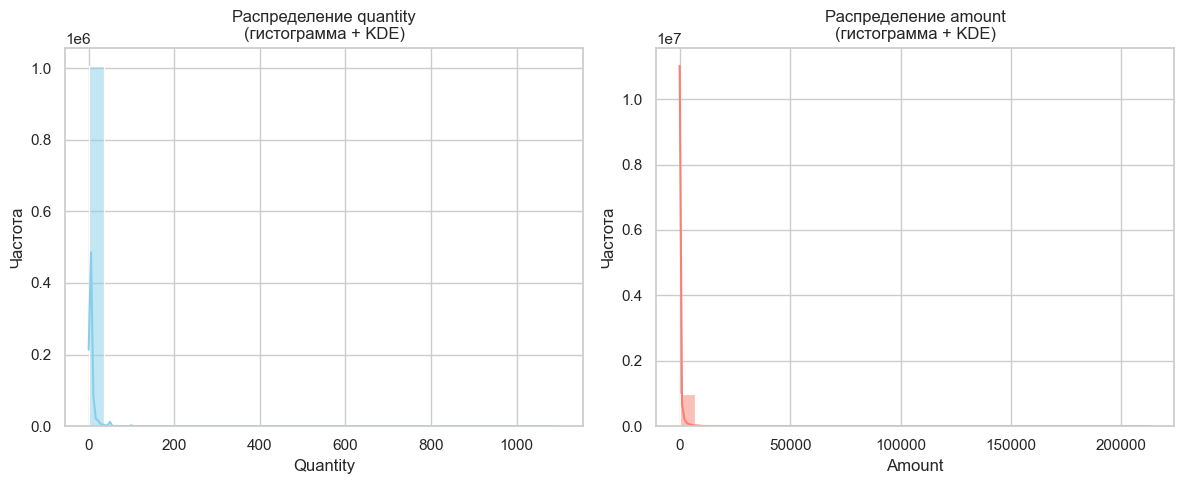

C:\Users\Alex\AppData\Local\Temp\ipykernel_16476\2262057060.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_melted, x='Переменная', y='Значение', palette='Set2')


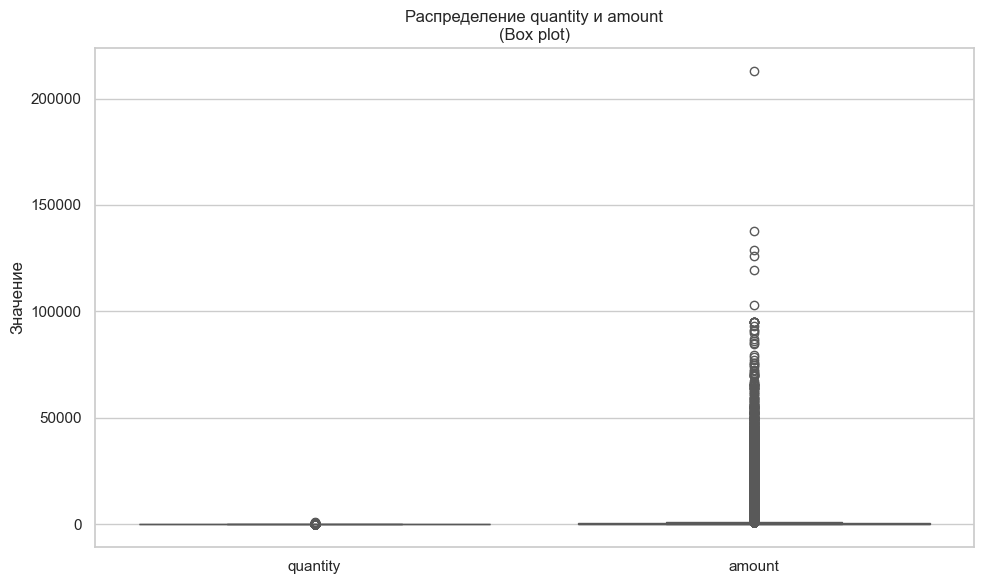

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Убедимся, что seaborn стилизован красиво
sns.set(style="whitegrid")

# Проверяем, что нужные колонки существуют
numeric_cols = ['quantity', 'amount']
if not all(col in df.columns for col in numeric_cols):
    missing = [col for col in numeric_cols if col not in df.columns]
    raise KeyError(f"Отсутствуют колонки: {missing}")

# =============================================
# ОКНО 1: Гистограммы с KDE
# =============================================
plt.figure(figsize=(12, 5))

# Гистограмма + KDE для quantity
plt.subplot(1, 2, 1)
sns.histplot(df['quantity'], kde=True, color='skyblue', bins=30)
plt.title('Распределение quantity\n(гистограмма + KDE)')
plt.xlabel('Quantity')
plt.ylabel('Частота')

# Гистограмма + KDE для amount
plt.subplot(1, 2, 2)
sns.histplot(df['amount'], kde=True, color='salmon', bins=30)
plt.title('Распределение amount\n(гистограмма + KDE)')
plt.xlabel('Amount')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

# =============================================
# ОКНО 2: Box plot'ы
# =============================================
plt.figure(figsize=(10, 6))

# Создаём данные в формате "long" для удобства построения
data_melted = df[numeric_cols].melt(value_vars=numeric_cols, var_name='Переменная', value_name='Значение')

# Box plot
sns.boxplot(data=data_melted, x='Переменная', y='Значение', palette='Set2')
plt.title('Распределение quantity и amount\n(Box plot)')
plt.ylabel('Значение')
plt.xlabel('')

plt.tight_layout()
plt.show()

На основе DataFrame с продажами:
1. Сгруппируй данные по колонке item (товар)
2. Для каждого товара рассчитай сумму двух метрик: - Кол-во:
sum(quantity) - Сумма продаж: sum(amount)
3. Отсортируй результат по сумме продаж в убывающем порядке
4. Выведи только ТОП-5 товаров с самыми большими продажами
5. Сохрани результат в переменную 'top_5_products'

In [15]:
# 1. Группировка по колонке 'item'
# 2. Расчёт суммы количества и суммы продаж
# 3. Сортировка по сумме продаж (по убыванию)
# 4. Выбор ТОП-5
top_5_products = (df.groupby('item')
                   .agg({'quantity': 'sum', 'amount': 'sum'})
                   .rename(columns={'quantity': 'Кол-во', 'amount': 'Сумма продаж'})
                   .sort_values(by='Сумма продаж', ascending=False)
                   .head(5))

# 5. Вывод результата
print("ТОП-5 товаров по сумме продаж:")
print(top_5_products)


ТОП-5 товаров по сумме продаж:
          Кол-во  Сумма продаж
item                          
sku26161   18902       5373638
sku18199    7250       3951361
sku21947   15304       3918570
sku28128    7705       3027786
sku8342     3512       2113158


Переделай предыдущий код так, чтобы число ТОП товаров было параметром
(переменной N). Создай функцию get_top_products(df, n=5), которая:
1. Принимает DataFrame df и параметр n (количество товаров)
2. Выполняет группировку, сортировку и фильтрацию как в предыдущем
примере
3. Возвращает DataFrame с n лучшими товарами Протестируй функцию с
разными значениями N

In [16]:
import pandas as pd

def get_top_products(df, n=5):
    """
    Возвращает ТОП-N товаров по сумме продаж.
    
    Параметры:
    df (pd.DataFrame): DataFrame с колонками 'item', 'quantity', 'amount'
    n (int): Количество топовых товаров для возврата (по умолчанию 5)
    
    Возвращает:
    pd.DataFrame: ТОП-N товаров с агрегированными 'Кол-во' и 'Сумма продаж', отсортированными по убыванию
    """
    # Проверка наличия нужных колонок
    required_cols = ['item', 'quantity', 'amount']
    if not all(col in df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        raise KeyError(f"Отсутствуют колонки: {missing}")
    
    top_n = (df.groupby('item')
              .agg({'quantity': 'sum', 'amount': 'sum'})
              .rename(columns={'quantity': 'Кол-во', 'amount': 'Сумма продаж'})
              .sort_values(by='Сумма продаж', ascending=False)
              .head(n))
    
    return top_n

# =============================================
# Тестирование функции с разными значениями N
# =============================================

# Пример 1: ТОП-5
print("ТОП-5 товаров:")
print(get_top_products(df, n=5))
print("\n" + "="*50)

# Пример 2: ТОП-3
print("ТОП-3 товара:")
print(get_top_products(df, n=3))
print("\n" + "="*50)

# Пример 3: ТОП-10
print("ТОП-10 товаров:")
print(get_top_products(df, n=10))

ТОП-5 товаров:
          Кол-во  Сумма продаж
item                          
sku26161   18902       5373638
sku18199    7250       3951361
sku21947   15304       3918570
sku28128    7705       3027786
sku8342     3512       2113158

ТОП-3 товара:
          Кол-во  Сумма продаж
item                          
sku26161   18902       5373638
sku18199    7250       3951361
sku21947   15304       3918570

ТОП-10 товаров:
          Кол-во  Сумма продаж
item                          
sku26161   18902       5373638
sku18199    7250       3951361
sku21947   15304       3918570
sku28128    7705       3027786
sku8342     3512       2113158
sku29626   13669       1973964
sku9018     3299       1706341
sku9471     5045       1675843
sku25074    6125       1668585
sku27791    8384       1645042


На основе исходного DataFrame:
1. Задай переменную end_date = '2019-10-31'
2. Задай переменную period_months = 6
3. Рассчитай начальную дату: start_date = end_date - 6 месяцев
4. Отфильтруй DataFrame так, чтобы осталась только дата >= start_date и дата <=
end_date
5. На отфильтрованных данных запусти функцию get_top_products(filtered_df, n=5)
6. Вывести результат

In [17]:
import pandas as pd
from dateutil.relativedelta import relativedelta

# Убедитесь, что колонка 'trDte' существует и имеет тип datetime
if 'trDte' not in df.columns:
    raise KeyError("Колонка 'trDte' не найдена. Проверьте, что дата была правильно загружена и переименована.")

# 1. Конечная дата
end_date = pd.to_datetime('2019-10-31')

# 2. Количество месяцев
period_months = 6

# 3. Начальная дата: end_date - 6 месяцев
start_date = end_date - relativedelta(months=period_months)

# 4. Фильтрация DataFrame по диапазону дат
filtered_df = df[(df['trDte'] >= start_date) & (df['trDte'] <= end_date)]

print(f"Фильтрация по периоду: с {start_date.date()} по {end_date.date()}")
print(f"Количество строк до фильтрации: {len(df)}")
print(f"Количество строк после фильтрации: {len(filtered_df)}\n")

# 5. Запуск функции get_top_products на отфильтрованных данных
top_5_recent = get_top_products(filtered_df, n=5)

# 6. Вывод результата
print("ТОП-5 товаров за последние 6 месяцев:")
print(top_5_recent)

Фильтрация по периоду: с 2019-04-30 по 2019-10-31
Количество строк до фильтрации: 1008688
Количество строк после фильтрации: 350864

ТОП-5 товаров за последние 6 месяцев:
          Кол-во  Сумма продаж
item                          
sku26161    7993       2379453
sku18199    3066       1848072
sku21947    5831       1543669
sku8342     1509        970053
sku22208      89        896275


На основе исходного DataFrame выполни анализ по клиентам:
1. Сгруппируй данные по client
2. Для каждого клиента рассчитай: - Общее количество
товаров (sum(quantity)) - Общую сумму закупок
(sum(amount)) - Количество уникальных дат визитов
3. Отсортируй по сумме закупок в убывающем порядке
4. Сохрани результат в переменную 'client_stats’. После
этого выведи статистику по столбцам: - Для quantity:
min, max, mean, median - Для amount: min, max, mean,
median - Для количества дат визитов: min, max, mean

In [18]:
import pandas as pd

# Проверка наличия нужных колонок
required_cols = ['clientID', 'quantity', 'amount', 'trDte']
if not all(col in df.columns for col in required_cols):
    missing = [col for col in required_cols if col not in df.columns]
    raise KeyError(f"Отсутствуют колонки: {missing}")

# 1-3. Группировка по клиенту и расчёт метрик
client_stats = (df.groupby('clientID')
                .agg({
                    'quantity': 'sum',                    # Общее количество товаров
                    'amount': 'sum',                      # Общая сумма закупок
                    'trDte': 'nunique'                  # Количество уникальных дат визитов
                })
                .rename(columns={
                    'quantity': 'Общее количество',
                    'amount': 'Общая сумма закупок',
                    'trDte': 'Количество визитов'
                })
                .sort_values(by='Общая сумма закупок', ascending=False))

# 4. Вывод статистики по ключевым метрикам
print("СТАТИСТИКА ПО КЛИЕНТАМ")
print("="*60)

# Статистика по количеству
print("По количеству товаров (Общее количество):")
print(f"  min:  {client_stats['Общее количество'].min()}")
print(f"  max:  {client_stats['Общее количество'].max()}")
print(f"  mean: {client_stats['Общее количество'].mean():.2f}")
print(f"  median: {client_stats['Общее количество'].median()}")

# Статистика по сумме закупок
print("\nПо сумме закупок (Общая сумма закупок):")
print(f"  min:  {client_stats['Общая сумма закупок'].min():.2f}")
print(f"  max:  {client_stats['Общая сумма закупок'].max():.2f}")
print(f"  mean: {client_stats['Общая сумма закупок'].mean():.2f}")
print(f"  median: {client_stats['Общая сумма закупок'].median():.2f}")

# Статистика по количеству визитов
print("\nПо количеству визитов:")
print(f"  min:  {client_stats['Количество визитов'].min()}")
print(f"  max:  {client_stats['Количество визитов'].max()}")
print(f"  mean: {client_stats['Количество визитов'].mean():.2f}")

# Дополнительно: показать ТОП-10 клиентов
print("\nТОП-10 клиентов по сумме закупок:")
print(client_stats.head(10))

СТАТИСТИКА ПО КЛИЕНТАМ
По количеству товаров (Общее количество):
  min:  1
  max:  5457
  mean: 52.44
  median: 21.0

По сумме закупок (Общая сумма закупок):
  min:  10.00
  max:  3887309.00
  mean: 14705.66
  median: 6410.00

По количеству визитов:
  min:  1
  max:  174
  mean: 6.18

ТОП-10 клиентов по сумме закупок:
             Общее количество  Общая сумма закупок  Количество визитов
clientID                                                              
client29182              3434              3887309                 107
client15654              5457              1443255                 174
client8778               1617               986618                  17
client1704               1187               636101                  23
client33032              1255               537397                  74
client37582              2526               502515                 159
client20512              1271               431752                  70
client6049               1963            

На основе датафрейма client_stats:
1. Отфильтруй клиентов, у которых: - Количество товаров >=
2000 ИЛИ - Сумма >= 500000
2. Выведи количество найденных клиентов и их список
3. Покажи эти клиентов с их основными характеристиками
4. Опционально: сохрани их ID для дальнейшего анализа в
список 'extreme_clients'

In [19]:
# 1. Фильтрация клиентов по условиям:
#    - Общее количество >= 2000 ИЛИ
#    - Общая сумма закупок >= 500000
filtered_clients = client_stats[
    (client_stats['Общее количество'] >= 2000) |
    (client_stats['Общая сумма закупок'] >= 500000)
]

# 2. Вывод количества и списка
print("ФИЛЬТРАЦИЯ КРУПНЫХ КЛИЕНТОВ")
print("=" * 60)
print(f"Количество клиентов, удовлетворяющих условиям: {len(filtered_clients)}")
print()

# 3. Вывод характеристик этих клиентов
if len(filtered_clients) > 0:
    print("Клиенты с высоким объемом закупок:")
    print(filtered_clients)
else:
    print("Клиенты, соответствующие критериям, не найдены.")

# 4. (Опционально) Сохранение ID клиентов в список
extreme_clients = filtered_clients.index.tolist()

print(f"\nСписок ID таких клиентов (extreme_clients):")
print(extreme_clients)

ФИЛЬТРАЦИЯ КРУПНЫХ КЛИЕНТОВ
Количество клиентов, удовлетворяющих условиям: 9

Клиенты с высоким объемом закупок:
             Общее количество  Общая сумма закупок  Количество визитов
clientID                                                              
client29182              3434              3887309                 107
client15654              5457              1443255                 174
client8778               1617               986618                  17
client1704               1187               636101                  23
client33032              1255               537397                  74
client37582              2526               502515                 159
client30977              2234               407138                 121
client34081              2470               386355                 157
client20310              3265               366035                 102

Список ID таких клиентов (extreme_clients):
['client29182', 'client15654', 'client8778', 'client1704', 'c

На основе датафрейма client_stats:
1. Отфильтруй клиентов, у которых количество дат визитов == 1
2. Подсчитай количество таких клиентов
3. Выведи статистику по этим клиентам: - Сколько их всего -
Какой средний чек у них - Какой средний объем покупок

In [20]:
# 1. Фильтрация клиентов с количеством визитов == 1
one_time_clients = client_stats[client_stats['Количество визитов'] == 1]

# 2. Подсчёт количества таких клиентов
n_one_time = len(one_time_clients)

# 3. Вывод статистики
print("АНАЛИЗ КЛИЕНТОВ С ОДНИМ ВИЗИТОМ")
print("=" * 50)
print(f"Количество клиентов с одним визитом: {n_one_time}")

if n_one_time > 0:
    # Средний чек = средняя сумма закупок
    avg_check = one_time_clients['Общая сумма закупок'].mean()
    
    # Средний объем покупок = среднее количество товаров
    avg_quantity = one_time_clients['Общее количество'].mean()
    
    print(f"Средний чек (средняя сумма покупки): {avg_check:.2f}")
    print(f"Средний объем покупок (количество товаров): {avg_quantity:.2f}")
else:
    print("Клиенты с одним визитом не найдены.")

АНАЛИЗ КЛИЕНТОВ С ОДНИМ ВИЗИТОМ
Количество клиентов с одним визитом: 12859
Средний чек (средняя сумма покупки): 3535.45
Средний объем покупок (количество товаров): 8.67


На основе исходного DataFrame:
1. Перед расчетом убедись, что нет строк с quantity = 0 (это может
привести к делению на 0) - Подсчитай количество таких строк - Если
есть, выведи их и удали из DataFrame
2. Создай новый столбец 'price' = amount / quantity
3. Выведи статистику по новому столбцу price: - min, max, mean, median
4. Выведи первые 10 строк исходного DataFrame + новый столбец price

In [21]:
# 1. Проверка и удаление строк с quantity = 0

# Подсчёт строк с quantity = 0
zero_quantity_rows = df[df['quantity'] == 0]

if len(zero_quantity_rows) > 0:
    print(f"Найдено {len(zero_quantity_rows)} строк с quantity = 0. Удаление...")
    print("\nПримеры таких строк:")
    print(zero_quantity_rows.head())  # Показываем первые несколько
    # Удаляем строки с quantity = 0
    df = df[df['quantity'] != 0].copy()
else:
    print("Строк с quantity = 0 не найдено.")

# 2. Создание столбца 'price' = amount / quantity
df['price'] = df['amount'] / df['quantity']

# 3. Статистика по новому столбцу 'price'
print("\nСТАТИСТИКА ПО ЦЕНЕ (price):")
print("=" * 40)
print(f"min:    {df['price'].min():.2f}")
print(f"max:    {df['price'].max():.2f}")
print(f"mean:   {df['price'].mean():.2f}")
print(f"median: {df['price'].median():.2f}")

# 4. Вывод первых 10 строк с новым столбцом
print("\nПЕРВЫЕ 10 СТРОК С НОВЫМ СТОЛБЦОМ 'price':")
print("=" * 50)
print(df[['trDte', 'bcode', 'clientID', 'item', 'quantity', 'amount', 'price']].head(10))

Найдено 1 строк с quantity = 0. Удаление...

Примеры таких строк:
            trDte          bcode     clientID      item         itemGroup  \
920771 2019-09-14  code000261741  client24307  sku26360  Скобяные изделия   

        quantity  amount  
920771         0       1  

СТАТИСТИКА ПО ЦЕНЕ (price):
min:    0.00
max:    119500.00
mean:   389.78
median: 102.89

ПЕРВЫЕ 10 СТРОК С НОВЫМ СТОЛБЦОМ 'price':
       trDte          bcode     clientID      item  quantity  amount  price
0 2017-09-01  code000000001  client13166   sku8444         1      29   29.0
1 2017-09-01  code000000001  client13166  sku12545         1     329  329.0
2 2017-09-01  code000000001  client13166   sku3391         1     169  169.0
3 2017-09-01  code000000001  client13166  sku20444         2     578  289.0
4 2017-09-01  code000000002   client1239  sku29959         1     329  329.0
5 2017-09-01  code000000002   client1239  sku19394         4     116   29.0
6 2017-09-01  code000000002   client1239   sku9916         4

На основе DataFrame с рассчитанной ценой товара:
1. Выведи описательную статистику столбца 'price': - Квартили
(25%, 50%, 75%) - Минимум и максимум - Межквартильный
диапазон (IQR = Q3 - Q1)
2. Рассчитай границы для потенциальных выбросов: - lower_bound
= Q1 - 1.5 * IQR - upper_bound = Q3 + 1.5 * IQR
3. Подсчитай количество выбросов (цены за пределами этих
границ)
4. Выведи примеры выбросов (10 самых дорогих и 10 самых дешевых
товаров) и создай визуализацию гистограммы и box plot

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Убедимся, что столбец 'price' существует
if 'price' not in df.columns:
    raise KeyError("Столбец 'price' не найден. Сначала рассчитайте цену: price = amount / quantity")

# Удаляем строки с NaN в price (если есть)
df = df.dropna(subset=['price'])

# =============================================
# 1. Описательная статистика и квартили
# =============import logging
logging.basicConfig(level=logging.INFO)
logging.info("Файл сохранён: %s", filename)
sns.histplot(..., log_scale=(False, True))
def abc_xyz_analysis(df, abc_threshold_a=80, abc_threshold_b=95):
    """
    Выполняет ABC-XYZ анализ для товаров на основе продаж и стабильности.

    Параметры
    ---------
    df : pd.DataFrame
        Должен содержать колонки: 'item', 'amount', 'quantity'
    abc_threshold_a : float, default 80
        Порог для группы A (в % от общей выручки)
    abc_threshold_b : float, default 95
        Порог для группы B

    Возвращает
    ----------
    pd.DataFrame
        С колонками: item, abc_group, xyz_group
    """
summary = df.groupby('item').agg(
    amount_sum=('amount', 'sum'),
    quantity_mean=('quantity', 'mean'),
    quantity_std=('quantity', 'std')
).reset_index()
def abc_xyz_analysis(df: pd.DataFrame, abc_threshold_a: float = 80) -> pd.DataFrame:
    # Проверка 1: пустой DataFrame
    if df.empty:
        raise ValueError("DataFrame пуст после фильтрации.")
if 'item' not in df.columns: raise KeyError
abc_xyz_all_time = ...
abc_xyz_last_6m = ...
def perform_abc_analysis(df, value_col='amount', thresholds=(80, 95)):
    """Выполняет ABC-анализ по указанной метрике."""
    ...

def perform_xyz_analysis(df, value_col='quantity'):
    """Выполняет XYZ-анализ по стабильности."""
    ...
recent_transactions = ...
filtered_data_6m = ...
#================================
print("1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ЦЕНЕ")
print("=" * 50)

# Квартили и основные значения
Q1 = df['price'].quantile(0.25)
Q2 = df['price'].quantile(0.50)  # медиана
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

min_price = df['price'].min()
max_price = df['price'].max()

print(f"Минимум:    {min_price:.2f}")
print(f"Q1 (25%):   {Q1:.2f}")
print(f"Медиана (50%): {Q2:.2f}")
print(f"Q3 (75%):   {Q3:.2f}")
print(f"Максимум:   {max_price:.2f}")
print(f"Межквартильный диапазон (IQR): {IQR:.2f}")

# =============================================
# 2. Границы выбросов
# =============================================
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n2. ГРАНИЦЫ ДЛЯ ВЫБРОСОВ")
print("=" * 50)
print(f"Нижняя граница (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"Верхняя граница (Q3 + 1.5*IQR): {upper_bound:.2f}")

# =============================================
# 3. Подсчёт выбросов
# =============================================
outliers_low = df[df['price'] < lower_bound]
outliers_high = df[df['price'] > upper_bound]
outliers = pd.concat([outliers_low, outliers_high])

print(f"\n3. КОЛИЧЕСТВО ВЫБРОСОВ")
print("=" * 50)
print(f"Выбросы ниже нижней границы: {len(outliers_low)}")
print(f"Выбросы выше верхней границы: {len(outliers_high)}")
print(f"Всего выбросов: {len(outliers)}")
print(f"Доля выбросов: {len(outliers) / len(df):.2%}")

# =============================================
# 4. Примеры выбросов
# =============================================
print(f"\n4. ПРИМЕРЫ ВЫБРОСОВ")
print("=" * 50)

print("\n10 самых дешёвых выбросов (ниже нижней границы):")
if len(outliers_low) > 0:
    print(outliers_low[['item', 'price', 'quantity', 'amount']].sort_values('price').head(10))
else:
    print("Нет выбросов снизу.")

print("\n10 самых дорогих выбросов (выше верхней границы):")
if len(outliers_high) > 0:
    print(outliers_high[['item', 'price', 'quantity', 'amount']].sort_values('price', ascending=False).head(10))
else:
    print("Нет выбросов сверху.")

# =============================================
# 5. Визуализация: гистограмма и box plot
# =============================================
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Гистограмма
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].axvline(x=lower_bound, color='red', linestyle='--', label=f'Нижняя граница: {lower_bound:.2f}')
axes[0].axvline(x=upper_bound, color='orange', linestyle='--', label=f'Верхняя граница: {upper_bound:.2f}')
axes[0].set_title('Распределение цены (гистограмма с KDE)')
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Box plot
sns.boxplot(x=df['price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Распределение цены (box plot)')
axes[1].set_xlabel('Цена')

plt.tight_layout()
plt.show()

NameError: name 'logging' is not defined

Выполни АВС-анализ товаров по сумме продаж:
1. Сгруппируй данные по item и рассчитай сумму продаж каждого
товара
2. Отсортируй товары по сумме продаж в убывающем порядке
3. Рассчитай накопительный процент (cumulative %) для каждого
товара: - Общая сумма всех продаж = total_sum - Для каждого
товара: cumulative_sum / total_sum * 100
4. На основе накопительного процента распредели товары на
группы: - Группа A: cumulative % <= 80% - Группа B:
cumulative % > 80% and <= 95% - Группа C: cumulative % > 95%
5. Выведи количество товаров в каждой группе и примеры товаров
из каждой группы

In [ ]:
import pandas as pd

# 1. Сгруппировать по товару и посчитать сумму продаж
sales_by_item = df.groupby('item')['amount'].sum().sort_values(ascending=False).reset_index()

# 2. Общая сумма продаж
total_sum = sales_by_item['amount'].sum()

# 3. Накопительная сумма и накопительный процент
sales_by_item['cumulative_sum'] = sales_by_item['amount'].cumsum()
sales_by_item['cumulative_percent'] = (sales_by_item['cumulative_sum'] / total_sum) * 100

# 4. Присвоение группы A, B, C
def assign_abc_group(percent):
    if percent <= 80:
        return 'A'
    elif percent <= 95:
        return 'B'
    else:
        return 'C'

sales_by_item['group'] = sales_by_item['cumulative_percent'].apply(assign_abc_group)

# Переименуем колонки для ясности
sales_by_item = sales_by_item.rename(columns={'amount': 'Сумма продаж'})

# 5. Вывод результатов
print("АВС-АНАЛИЗ ТОВАРОВ ПО СУММЕ ПРОДАЖ")
print("=" * 60)

# Количество товаров в каждой группе
group_counts = sales_by_item['group'].value_counts().sort_index()
print("Количество товаров в каждой группе:")
print(f"Группа A (до 80%): {group_counts.get('A', 0)}")
print(f"Группа B (80–95%): {group_counts.get('B', 0)}")
print(f"Группа C (свыше 95%): {group_counts.get('C', 0)}")
print()

# Примеры товаров из каждой группы
for group in ['A', 'B', 'C']:
    group_data = sales_by_item[sales_by_item['group'] == group]
    print(f"Примеры товаров из группы {group} (до 5 шт.):")
    if len(group_data) > 0:
        print(group_data[['item', 'Сумма продаж', 'cumulative_percent']].head().to_string(index=False))
    else:
        print("Нет товаров.")
    print("-" * 40)

# (Опционально) Сохранение результата в переменную
abc_analysis = sales_by_item[['item', 'Сумма продаж', 'cumulative_percent', 'group']].copy()

АВС-АНАЛИЗ ТОВАРОВ ПО СУММЕ ПРОДАЖ
Количество товаров в каждой группе:
Группа A (до 80%): 5353
Группа B (80–95%): 8234
Группа C (свыше 95%): 16979

Примеры товаров из группы A (до 5 шт.):
    item  Сумма продаж  cumulative_percent
sku26161       5373638            0.854847
sku18199       3951361            1.483435
sku21947       3918570            2.106808
sku28128       3027786            2.588473
 sku8342       2113158            2.924637
----------------------------------------
Примеры товаров из группы B (до 5 шт.):
    item  Сумма продаж  cumulative_percent
sku10822         22836           80.001791
sku10724         22834           80.005424
sku29015         22826           80.009055
sku26094         22824           80.012686
sku19581         22817           80.016316
----------------------------------------
Примеры товаров из группы C (до 5 шт.):
    item  Сумма продаж  cumulative_percent
sku18189          5357           95.000265
sku13438          5357           95.001117
  sku

Дополни XYZ-анализ товаров (по количеству): Используй
для расчета коэффициент вариации = std / mean * 100. На
основе коэффициента вариации распредели товары: -
Группа X: CV < 15% - Группа Y: 15% <= CV <= 25% -
Группа Z: CV > 25%. Выведи количество товаров в каждой
группе и итоговый датафрейм.

In [ ]:
import pandas as pd

# 1. Сгруппировать по товару и посчитать статистику по quantity
xyz_data = df.groupby('item')['quantity'].agg(['sum', 'mean', 'std']).reset_index()

# Переименуем для ясности
xyz_data = xyz_data.rename(columns={
    'sum': 'Общее количество',
    'mean': 'Среднее количество',
    'std': 'Стандартное отклонение'
})

# 2. Рассчитать коэффициент вариации (CV) = std / mean * 100
# Обработка случаев, где mean = 0 (защита от деления на 0)
xyz_data['CV (%)'] = xyz_data.apply(
    lambda row: (row['Стандартное отклонение'] / row['Среднее количество']) * 100 
    if row['Среднее количество'] > 0 else 0, axis=1
)

# Заполним NaN (если std = 0 и mean = 0)
xyz_data['CV (%)'] = xyz_data['CV (%)'].fillna(0)

# 3. Присвоить XYZ-группу
def assign_xyz_group(cv):
    if cv < 15:
        return 'X'
    elif 15 <= cv <= 25:
        return 'Y'
    else:
        return 'Z'

xyz_data['xyz_group'] = xyz_data['CV (%)'].apply(assign_xyz_group)

# 4. Вывод результатов
print("XYZ-АНАЛИЗ ТОВАРОВ ПО СТАБИЛЬНОСТИ ПРОДАЖ (по quantity)")
print("=" * 70)

group_counts = xyz_data['xyz_group'].value_counts().sort_index()
print("Количество товаров в каждой группе:")
print(f"Группа X (CV < 15%):  {group_counts.get('X', 0)} — стабильный спрос")
print(f"Группа Y (15% ≤ CV ≤ 25%): {group_counts.get('Y', 0)} — умеренно изменчивый спрос")
print(f"Группа Z (CV > 25%): {group_counts.get('Z', 0)} — нестабильный, случайный спрос")
print()

# Примеры из каждой группы
for group in ['X', 'Y', 'Z']:
    group_data = xyz_data[xyz_data['xyz_group'] == group]
    print(f"Примеры товаров из группы {group}:")
    if len(group_data) > 0:
        print(group_data[['item', 'Среднее количество', 'Стандартное отклонение', 'CV (%)']]
              .head(3).round(2).to_string(index=False))
    else:
        print("Нет товаров.")
    print("-" * 50)

# 5. Итоговый датафрейм XYZ-анализа
xyz_analysis = xyz_data[['item', 'Среднее количество', 'Стандартное отклонение', 'CV (%)', 'xyz_group']].copy()

XYZ-АНАЛИЗ ТОВАРОВ ПО СТАБИЛЬНОСТИ ПРОДАЖ (по quantity)
Количество товаров в каждой группе:
Группа X (CV < 15%):  11655 — стабильный спрос
Группа Y (15% ≤ CV ≤ 25%): 1354 — умеренно изменчивый спрос
Группа Z (CV > 25%): 17557 — нестабильный, случайный спрос

Примеры товаров из группы X:
    item  Среднее количество  Стандартное отклонение  CV (%)
sku10002                 1.0                     0.0     0.0
sku10003                 1.0                     0.0     0.0
sku10005                 1.0                     0.0     0.0
--------------------------------------------------
Примеры товаров из группы Y:
    item  Среднее количество  Стандартное отклонение  CV (%)
sku10009                1.02                    0.16   15.43
sku10011                1.06                    0.24   22.91
sku10016                3.50                    0.71   20.20
--------------------------------------------------
Примеры товаров из группы Z:
  item  Среднее количество  Стандартное отклонение  CV (%)
  sku

Создай перекрестную таблицу (pivot table) АВС группа x
XYZ группа для матрицы ABC-XYZ

МАТРИЦА ABC-XYZ (количество товаров в каждой группе)
xyz_group     X    Y     Z
group                     
A          1527  297  3529
B          2562  411  5261
C          7566  646  8767

xyz_group     X    Y     Z
ABC \ XYZ                 
A          1527  297  3529
B          2562  411  5261
C          7566  646  8767


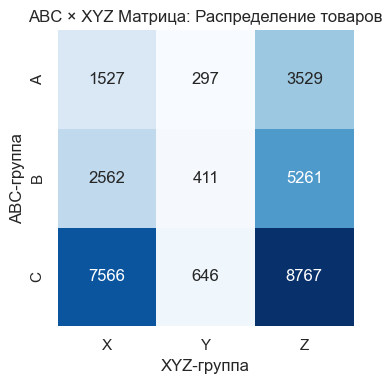

In [ ]:
import pandas as pd

# Убедимся, что у нас есть:
# - abc_analysis: с колонками 'item', 'group' (A/B/C)
# - xyz_analysis: с колонками 'item', 'xyz_group' (X/Y/Z)

# 1. Объединим данные ABC и XYZ по товару
abc_xyz = pd.merge(
    abc_analysis[['item', 'group']],
    xyz_analysis[['item', 'xyz_group']],
    on='item',
    how='inner'
)

# 2. Создадим сводную таблицу (pivot table): количество товаров в каждой ячейке матрицы
pivot_abc_xyz = pd.pivot_table(
    abc_xyz,
    index='group',           # ABC по строкам
    columns='xyz_group',     # XYZ по столбцам
    values='item',
    aggfunc='count',
    fill_value=0
)

# 3. Вывод матрицы
print("МАТРИЦА ABC-XYZ (количество товаров в каждой группе)")
print("=" * 60)
print(pivot_abc_xyz)
print()

# Дополнительно: красивое отображение с названиями групп
pivot_abc_xyz.index.name = 'ABC \ XYZ'
print(pivot_abc_xyz.to_string())

# 4. (Опционально) Визуализация матрицы
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    pivot_abc_xyz,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True
)
plt.title("ABC × XYZ Матрица: Распределение товаров")
plt.ylabel("ABC-группа")
plt.xlabel("XYZ-группа")
plt.tight_layout()
plt.show()

1. Создай функцию abc_xyz_analysis(df, abc_threshold_a=80,
abc_threshold_b=95):
a) Которая выполняет весь АВС-XYZ анализ из предыдущих
инструкций
b) Параметры позволяют менять границы групп А и В 2.
Отфильтруй исходный DataFrame за последние 6 месяцев (с
01.05.2019 по 31.10.2019)
2. 3апусти функцию на отфильтрованных данных:
abc_xyz_analysis(df_last_6m)
3. Сравни результаты за весь период и за последние 6 месяцев:
a) Сколько товаров перешло из группы в группу?
b) Какие товары стали важнее?
c) Какие - менее важны?
Используй только товары, которые есть в обоих периодах

In [ ]:
import pandas as pd
from dateutil.relativedelta import relativedelta
import numpy as np

def abc_xyz_analysis(df, abc_threshold_a=80, abc_threshold_b=95):
    """
    Полный ABC-XYZ анализ с гибкими порогами для ABC.
    
    Параметры:
    df (pd.DataFrame): исходный DataFrame с колонками 'item', 'amount', 'quantity', 'tr_date'
    abc_threshold_a (float): граница для группы A (по умолч. 80%)
    abc_threshold_b (float): граница для группы B (по умолч. 95%)
    
    Возвращает:
    pd.DataFrame с колонками: item, abc_group, xyz_group
    """
    
    # Проверка колонок
    required = ['item', 'amount', 'quantity']
    if not all(col in df.columns for col in required):
        raise KeyError(f"Не хватает колонок: {set(required) - set(df.columns)}")
    
    # === ABC-анализ по сумме продаж ===
    abc = (df.groupby('item')['amount']
           .sum()
           .sort_values(ascending=False)
           .reset_index())
    
    total_sales = abc['amount'].sum()
    abc['cumulative_sum'] = abc['amount'].cumsum()
    abc['cumulative_percent'] = (abc['cumulative_sum'] / total_sales) * 100
    
    def assign_abc(percent):
        if percent <= abc_threshold_a:
            return 'A'
        elif percent <= abc_threshold_b:
            return 'B'
        else:
            return 'C'
    
    abc['abc_group'] = abc['cumulative_percent'].apply(assign_abc)
    
    # === XYZ-анализ по стабильности quantity ===
    xyz = df.groupby('item')['quantity'].agg(['mean', 'std']).reset_index()
    xyz['cv'] = xyz.apply(
        lambda row: (row['std'] / row['mean'] * 100) if row['mean'] > 0 else 0, axis=1
    )
    xyz['cv'] = xyz['cv'].fillna(0)
    
    def assign_xyz(cv):
        if cv < 15:
            return 'X'
        elif 15 <= cv <= 25:
            return 'Y'
        else:
            return 'Z'
    
    xyz['xyz_group'] = xyz['cv'].apply(assign_xyz)
    
    # === Объединение ABC и XYZ ===
    result = pd.merge(abc[['item', 'abc_group']], xyz[['item', 'xyz_group']], on='item')
    return result

# ===================================================
# 2. Фильтрация за последние 6 месяцев
# ===================================================
# Преобразуем, если ещё не datetime
df['trDte'] = pd.to_datetime(df['trDte'])

end_date = pd.to_datetime('2019-10-31')
start_date = end_date - relativedelta(months=6)

df_last_6m = df[(df['trDte'] >= start_date) & (df['trDte'] <= end_date)]

print(f"Фильтрация: с {start_date.date()} по {end_date.date()}")
print(f"Строк до: {len(df)}, после: {len(df_last_6m)}\n")

# ===================================================
# 3. Запуск анализа для двух периодов
# ===================================================
# Весь период
abc_xyz_full = abc_xyz_analysis(df)
abc_xyz_full = abc_xyz_full.set_index('item').sort_index()

# Последние 6 месяцев
abc_xyz_recent = abc_xyz_analysis(df_last_6m)
abc_xyz_recent = abc_xyz_recent.set_index('item').sort_index()

# ===================================================
# 4. Сравнение: только общие товары
# ===================================================
common_items = abc_xyz_full.join(abc_xyz_recent, 
                                 how='inner', 
                                 lsuffix='_full', 
                                 rsuffix='_recent')

common_items = common_items.reset_index()

# Сравнение групп
changed = common_items[
    (common_items['abc_group_full'] != common_items['abc_group_recent']) |
    (common_items['xyz_group_full'] != common_items['xyz_group_recent'])
]

print("СРАВНЕНИЕ ABC-XYZ ПО ДВУМ ПЕРИОДАМ")
print("=" * 60)
print(f"Общее количество товаров: {len(common_items)}")
print(f"Количество товаров с изменением группы: {len(changed)}")
print(f"Доля изменений: {len(changed) / len(common_items):.1%}\n")

# a) Сколько перешло из группы в группу?
print("ПЕРЕХОДЫ ТОВАРОВ МЕЖДУ ГРУППАМИ:")
print("-" * 40)
# ABC изменения
abc_changes = changed[changed['abc_group_full'] != changed['abc_group_recent']]
if len(abc_changes) > 0:
    print("Изменения в ABC-группе:")
    for _, row in abc_changes.iterrows():
        print(f"{row['item']}: {row['abc_group_full']} → {row['abc_group_recent']} (ABC)")
else:
    print("Изменений в ABC-группе нет.")

# XYZ изменения
xyz_changes = changed[changed['xyz_group_full'] != changed['xyz_group_recent']]
if len(xyz_changes) > 0 and len(xyz_changes) != len(abc_changes):
    print("\nИзменения в XYZ-группе:")
    for _, row in xyz_changes.iterrows():
        print(f"{row['item']}: {row['xyz_group_full']} → {row['xyz_group_recent']} (XYZ)")

# b) Какие товары стали важнее / менее важны?
print("\nАНАЛИЗ ДИНАМИКИ ВАЖНОСТИ:")
print("-" * 40)

# Улучшение: повысили ABC (A лучше B, B лучше C)
def rank_abc(group):
    return {'A': 3, 'B': 2, 'C': 1}[group]

common_items['importance_full'] = common_items['abc_group_full'].apply(rank_abc)
common_items['importance_recent'] = common_items['abc_group_recent'].apply(rank_abc)

# Ставшие важнее: ABC повысился
more_important = common_items[common_items['importance_recent'] > common_items['importance_full']]
if len(more_important) > 0:
    print("Ставшие важнее (ABC улучшился):")
    for _, row in more_important.iterrows():
        print(f"  {row['item']}: {row['abc_group_full']} → {row['abc_group_recent']}")

# Ставшие менее важные
less_important = common_items[common_items['importance_recent'] < common_items['importance_full']]
if len(less_important) > 0:
    print("Ставшие менее важными (ABC ухудшился):")
    for _, row in less_important.iterrows():
        print(f"  {row['item']}: {row['abc_group_full']} → {row['abc_group_recent']}")

# Резюме
print(f"\nРЕЗЮМЕ:")
print(f"- {len(more_important)} товара стали важнее")
print(f"- {len(less_important)} товара стали менее важны")
print(f"- {len(common_items) - len(changed)} товара остались в тех же группах")

Фильтрация: с 2019-04-30 по 2019-10-31
Строк до: 1008687, после: 350863

СРАВНЕНИЕ ABC-XYZ ПО ДВУМ ПЕРИОДАМ
Общее количество товаров: 21824
Количество товаров с изменением группы: 7497
Доля изменений: 34.4%

ПЕРЕХОДЫ ТОВАРОВ МЕЖДУ ГРУППАМИ:
----------------------------------------
Изменения в ABC-группе:
sku10000: B → C (ABC)
sku10013: B → A (ABC)
sku10015: B → C (ABC)
sku10016: C → B (ABC)
sku10020: B → C (ABC)
sku10027: B → C (ABC)
sku10029: B → A (ABC)
sku10033: B → C (ABC)
sku10047: C → B (ABC)
sku10052: B → C (ABC)
sku10061: A → B (ABC)
sku10069: A → B (ABC)
sku10073: A → B (ABC)
sku10077: B → C (ABC)
sku10079: B → C (ABC)
sku10088: A → B (ABC)
sku1009: A → B (ABC)
sku101: B → A (ABC)
sku10100: B → C (ABC)
sku10102: B → C (ABC)
sku10104: B → C (ABC)
sku10120: A → B (ABC)
sku10121: B → A (ABC)
sku10134: A → B (ABC)
sku10138: A → B (ABC)
sku10139: A → B (ABC)
sku10151: B → C (ABC)
sku10153: C → B (ABC)
sku10156: B → C (ABC)
sku10160: C → B (ABC)
sku10163: B → C (ABC)
sku10172: B → C

Сохрани результаты анализа в CSV файлы:
1. Результаты ТОП-5 товаров → 'top_5_products.csv' 2.
2. Статистику по клиентам → 'client_statistics.csv’
3. АВС-анализ товаров → 'abc_analysis.csv’
4. XYZ-анализ товаров → 'xyz_analysis.csv’
5. Матрицу ABC-XYZ → 'abc_xyz_matrix.csv’
6. Данные за последние 6 месяцев → 'last_6_months_data.csv’.
Используй method='w', index=False для сохранения без индекса
Проверь, что файлы успешно созданы, выведи первые 5 строк
каждого файла

In [ ]:
import os

# Список файлов для сохранения
files_to_save = [
    ('top_5_products.csv', top_5_products.reset_index()),  # top_5_products может иметь индекс item
    ('client_statistics.csv', client_stats.reset_index()),  # client_stats использует client как индекс
    ('abc_analysis.csv', abc_analysis),
    ('xyz_analysis.csv', xyz_analysis),
    ('abc_xyz_matrix.csv', pivot_abc_xyz.reset_index()),   # pivot-таблица: делаем group столбцом
    ('last_6_months_data.csv', df_last_6m)                 # отфильтрованный исходный DataFrame
]

# Сохранение файлов
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В CSV")
print("=" * 60)

for filename, data in files_to_save:
    data.to_csv(filename, index=False, encoding='utf-8')
    print(f"✅ Сохранено: {filename} ({len(data)} строк)")

print("\n" + "=" * 60)
print("ПРОВЕРКА: первые 5 строк каждого файла")
print("=" * 60)

# Чтение и вывод первых 5 строк каждого файла
for filename, _ in files_to_save:
    if os.path.exists(filename):
        df_check = pd.read_csv(filename)
        print(f"\n📄 {filename}:")
        print(df_check.head())
    else:
        print(f"❌ Файл не найден: {filename}")

СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В CSV
✅ Сохранено: top_5_products.csv (5 строк)
✅ Сохранено: client_statistics.csv (42746 строк)
✅ Сохранено: abc_analysis.csv (30566 строк)
✅ Сохранено: xyz_analysis.csv (30566 строк)
✅ Сохранено: abc_xyz_matrix.csv (3 строк)
✅ Сохранено: last_6_months_data.csv (350863 строк)

ПРОВЕРКА: первые 5 строк каждого файла

📄 top_5_products.csv:
       item  Кол-во  Сумма продаж
0  sku26161   18902       5373638
1  sku18199    7250       3951361
2  sku21947   15304       3918570
3  sku28128    7705       3027786
4   sku8342    3512       2113158

📄 client_statistics.csv:
      clientID  Общее количество  Общая сумма закупок  Количество визитов
0  client29182              3434              3887309                 107
1  client15654              5457              1443255                 174
2   client8778              1617               986618                  17
3   client1704              1187               636101                  23
4  client33032              1255    